# Exploratory Data Analysis (EDA)

This notebook contains the steps for performing exploratory data analysis (EDA) on the PV dataset.

## 0. Heat Map

Firstly, we'll do a heat map to check if there are any high correlation values that allow us to remove any variable.

The default coefficient used in the correlation function is the Pearson correlation coefficient. This is a descriptive statistic, that describes the strength and direction of the linear relationship between two quantitative variables.

The Pearson correlation coefficient is a good choice when all of the following are true:
1. Both variables are quantitative;
2. The variables are normally distributed;
3. The data has no outliers;
4. The relationship is linear.

Therefore we will first check if a feature meets these requirements and if not, we will use other coefficients to measure the correlation. For features that are not normally distributed we will use the Spearman coefficient, which is better for variables that aren't normally distributed or exhibit non-linear trends. For binary features, we will use the point-biserial correlation, that measures the correlation between a binary variable (treated as 0 and 1) and a continuous variable. This is a special case of the Pearson correlation (https://stats.stackexchange.com/questions/105542/proof-of-point-biserial-correlation-being-a-special-case-of-pearson-correlation).


c:\Users\Utilizador\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 80000.
  res = hypotest_fun_out(*samples, **kwds)


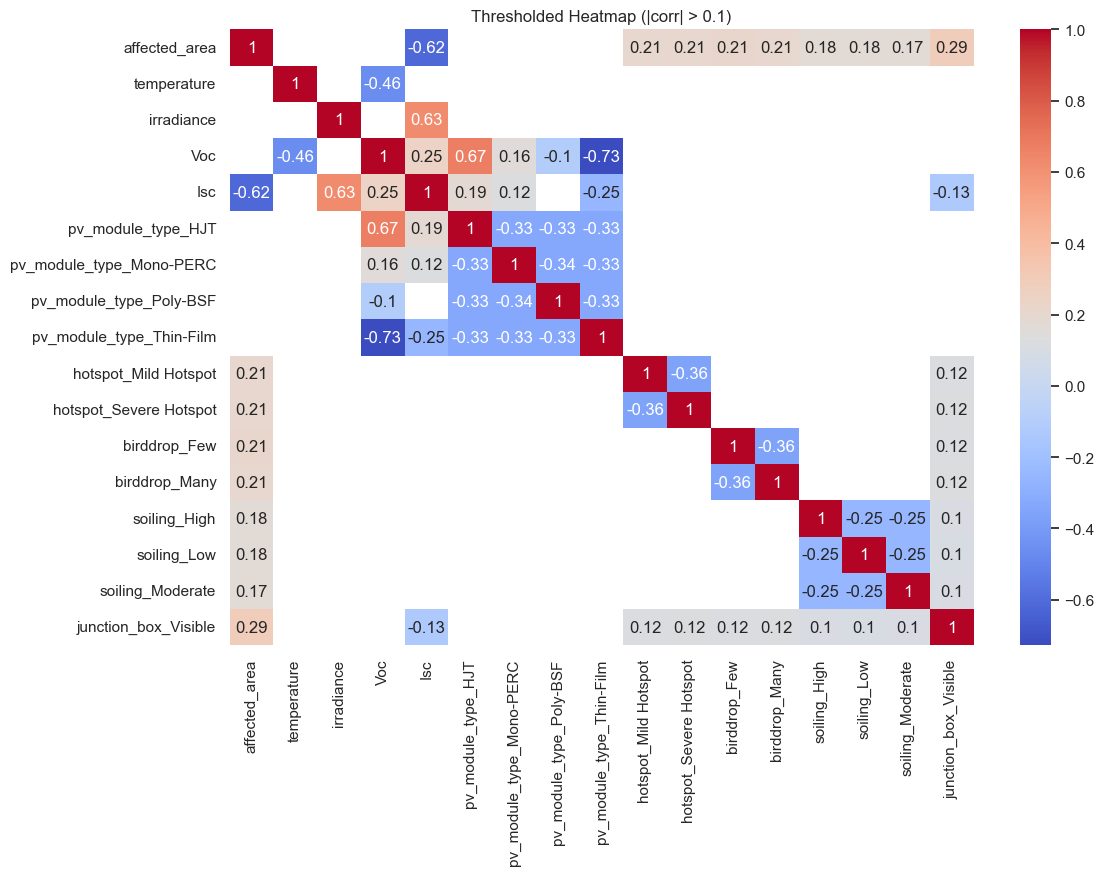

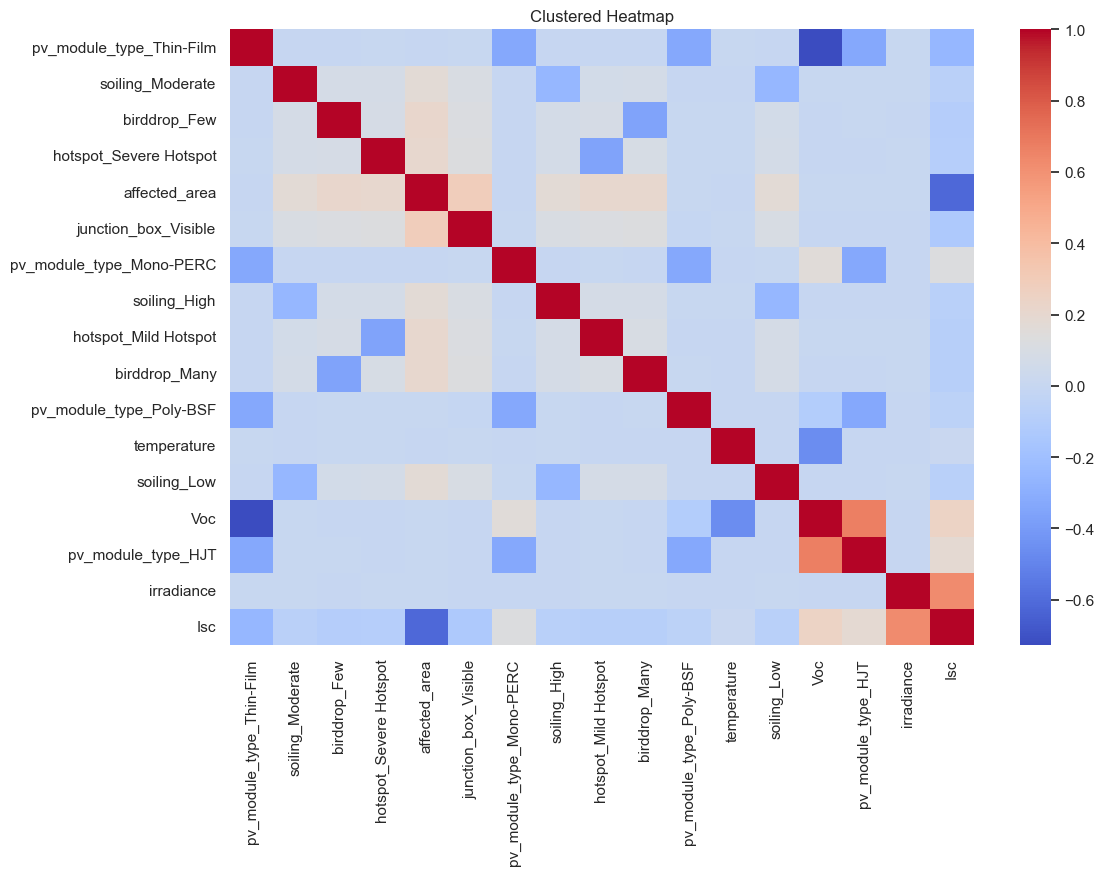

In [12]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, pointbiserialr, shapiro
from scipy.cluster.hierarchy import linkage, leaves_list

# Define the file path relative to the current notebook directory
file_path = os.path.join("..", "data", "processed", "X_train_scaled.csv")

# Check if the file exists
if not os.path.exists(file_path):
    raise FileNotFoundError(f"The file {file_path} does not exist. Please check the path and try again.")

# Load preprocessed data
data = pd.read_csv(file_path)

# Define a function to test normality
def is_normal(col):
    stat, p_value = shapiro(col)
    return p_value > 0.05

# Calculate pairwise correlations
correlations = {}

for col in data.columns:
    for target_col in data.columns:
        if col == target_col:  # Skip self-correlation
            correlations[(col, target_col)] = 1.0
        elif (target_col, col) in correlations:  # Skip redundant pairs
            correlations[(col, target_col)] = correlations[(target_col, col)]
        else:
            if data[col].nunique() > 2:  # Continuous variable
                if is_normal(data[col]) and is_normal(data[target_col]):  # Use Pearson if both are normal
                    corr, _ = pearsonr(data[col], data[target_col])
                else:  # Use Spearman otherwise
                    corr, _ = spearmanr(data[col], data[target_col])
            elif data[col].nunique() == 2 or data[target_col].nunique() == 2:  # Binary variable
                # Use Point-Biserial for binary variables
                if data[col].nunique() == 2:
                    corr, _ = pointbiserialr(data[col], data[target_col])
                else:
                    corr, _ = pointbiserialr(data[target_col], data[col])
            else:  # Default to Spearman if unsure
                corr, _ = spearmanr(data[col], data[target_col])
            correlations[(col, target_col)] = corr

# Convert to DataFrame
corr_matrix = pd.DataFrame(
    {col: {row: correlations.get((row, col), np.nan) for row in data.columns} for col in data.columns}
)

# Apply threshold to correlation matrix
threshold = 0.1
thresholded_corr = corr_matrix.where((corr_matrix > threshold) | (corr_matrix < -threshold), np.nan)

# Plot the Thresholded Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(thresholded_corr, annot=True, cmap='coolwarm', mask=thresholded_corr.isnull())
plt.grid(False)
plt.title('Thresholded Heatmap (|corr| > 0.1)')
plt.show()

# Perform hierarchical clustering on the correlation matrix
linkage_matrix = linkage(corr_matrix.fillna(0), method='ward')
ordered_indices = leaves_list(linkage_matrix)
clustered_corr = corr_matrix.iloc[ordered_indices, ordered_indices]

# Plot the Clustered Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(clustered_corr, annot=False, cmap='coolwarm')
plt.title('Clustered Heatmap')
plt.show()


Since none of the pairs has a correlation value equal or superior to 0.80 (maximum value in the data: 0.73), we can consider there are no features with an extremelly high correlation value. This means there is no immediate need to remove highly colinear features. 

However, there are still some actions we can do to improve our data quality and our models's performance, like:
1. evaluation of the relation between features through scatter plots;
2. analysis of the correlation related to the target variable; and
3. reduction of the dimension (through PCA).

## 1. Analysis of the scatter plots

In this analysis, we load preprocessed training data along with the target variable and visualize the relationships between each feature and the target using scatter plots. These plots allow us to visually inspect the correlation between each feature and the target variable, helping to identify trends or patterns that may not be immediately apparent in numerical summaries alone.

By examining the scatter plots, we can assess the strength and direction of the relationships. Features that exhibit a strong or clear linear relationship with the target should be retained for further analysis, while those showing weak or no distinct relationship may be considered for removal to simplify the model. The code below demonstrates how to generate and interpret these scatter plots.

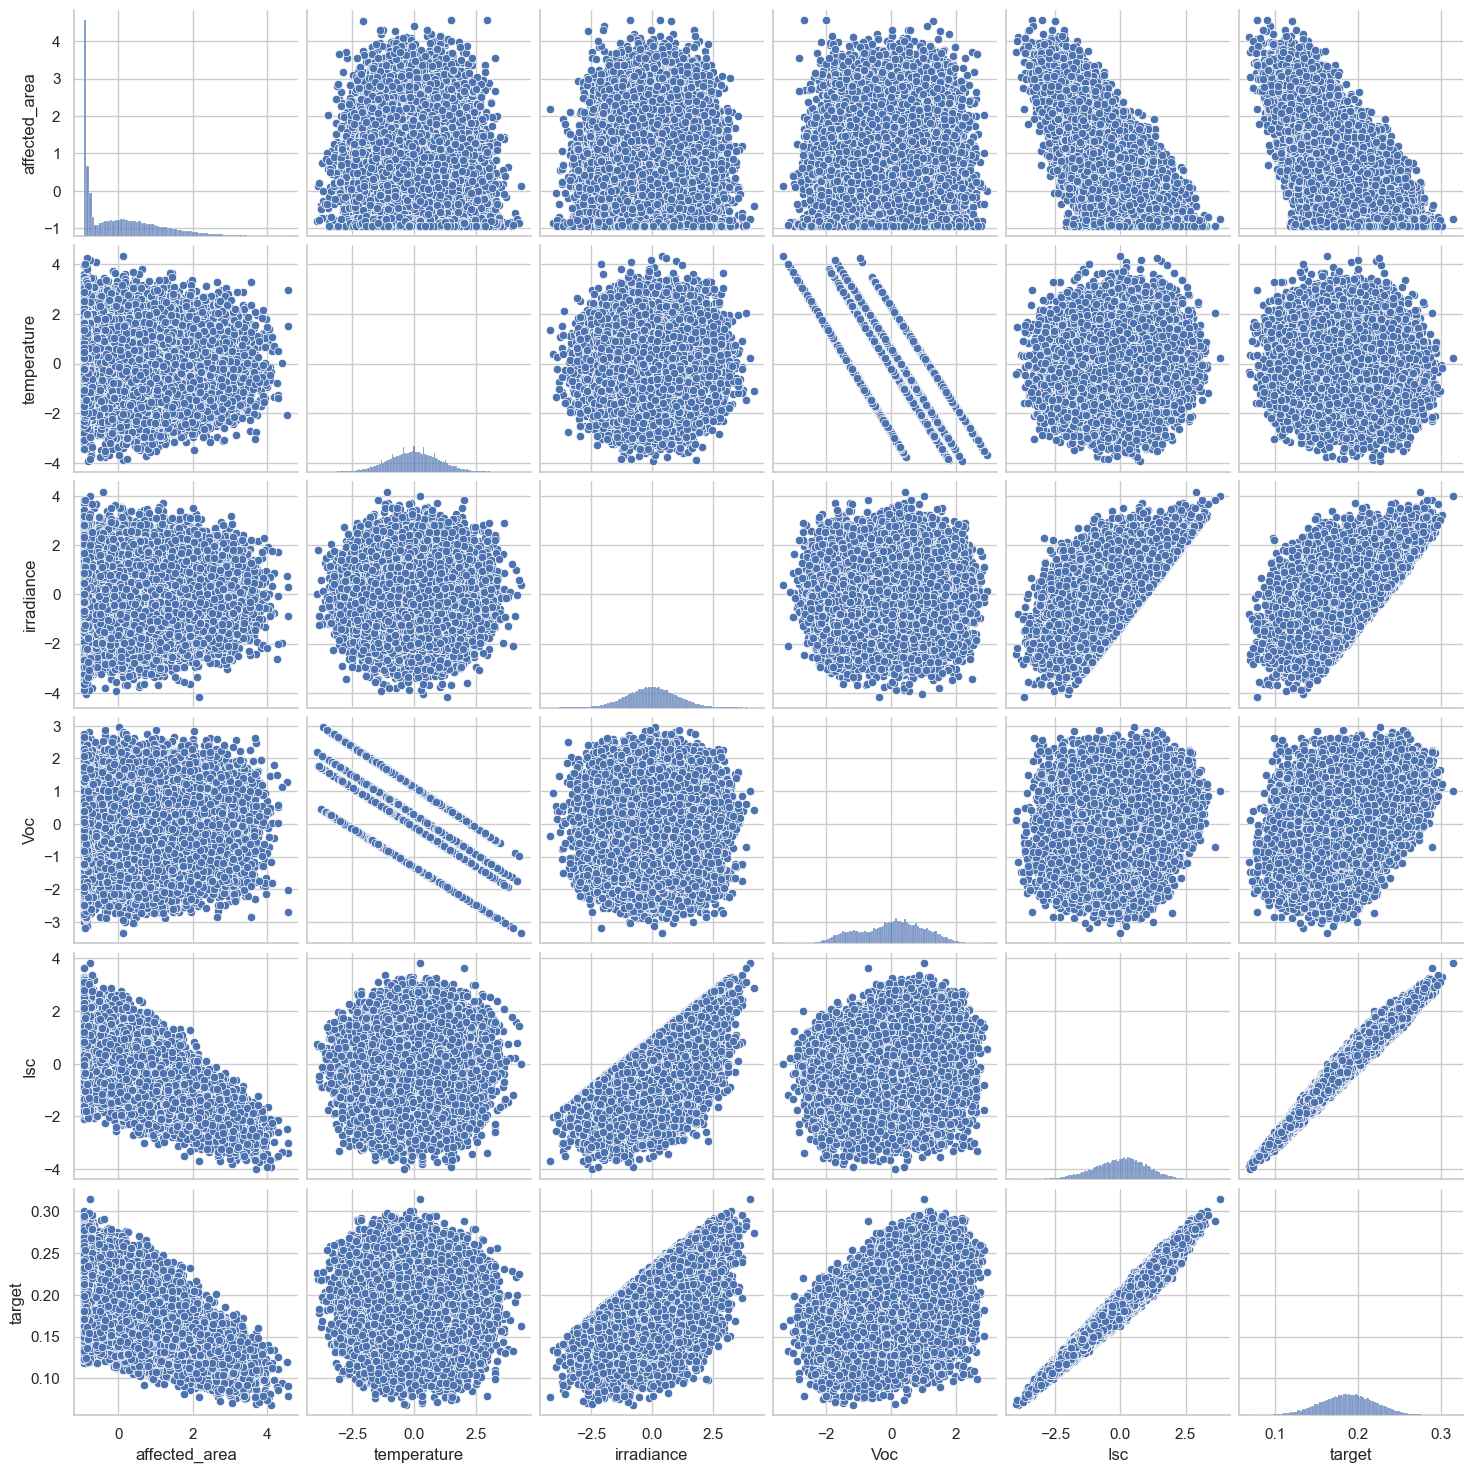

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, kstest, anderson
import os

# Load preprocessed data
file_path = os.path.join("..", "data", "processed", "X_train_scaled.csv")
X_train = pd.read_csv(file_path)

# Loading the target variable
target_path = os.path.join("..", "data", "processed", "y_efficiency_train.csv")
y_train = pd.read_csv(target_path).values.ravel()

# Create a DataFrame with features and target
data = X_train.copy()
data['target'] = y_train

continuous_columns = [col for col in data.columns if data[col].nunique() > 2]

# Pairwise scatterplots
sns.pairplot(data[continuous_columns])
plt.show()



The scatter plots only show two strong relations: Isc with the target and Voc with temperature. There are also some weak relations shown in the plots, like the irradiance and the affected area with the target. However, the strong correlation between Voc and temperature had not been represented in the previously presented heatmap.

In fact, the scatter plot of VOC versus temperature reveals distinct clusters, indicating the presence of subgroups within the data, which can not be captured by a simple Pearson or Spearment correlation. These clusters suggest that the relationship between VOC and temperature may be influenced by an unobserved factor, such as differing environmental conditions, seasonal changes, operating modes, or measurement settings. Within each cluster, the relationship remains consistent and follows an inverse linear pattern, reinforcing the idea that temperature strongly influences VOC levels. However, the offsets between the clusters highlight variability introduced by external factors, which are not currently accounted for in the dataset. To address this, additional parameters could be created to represent the cluster each data point belongs to, serving as proxies for these hidden variables. Incorporating these parameters into predictive models could improve accuracy and provide more context-aware insights. However, the usefulness of such an approach would depend on the feature importance derived from the models. If these new parameters are not deemed significant by the models, it may not be necessary to explore this avenue further.

## 2. Analysis of the Correlation (to the target variable)

In this analysis, we load preprocessed training data and the target variable, then calculate the correlation of each feature with the target variable. 

This allows us to easily identify and interpret the significance of each feature in relation to the target. Features with strong or very strong correlations should be retained for further analysis, while those with weak correlations may be considered for removal to simplify the model. The code below implements this approach:

c:\Users\Utilizador\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 80000.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\Utilizador\AppData\Local\Temp\ipykernel_17880\2076906919.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations_series.values, y=correlations_series.index, palette=colors)


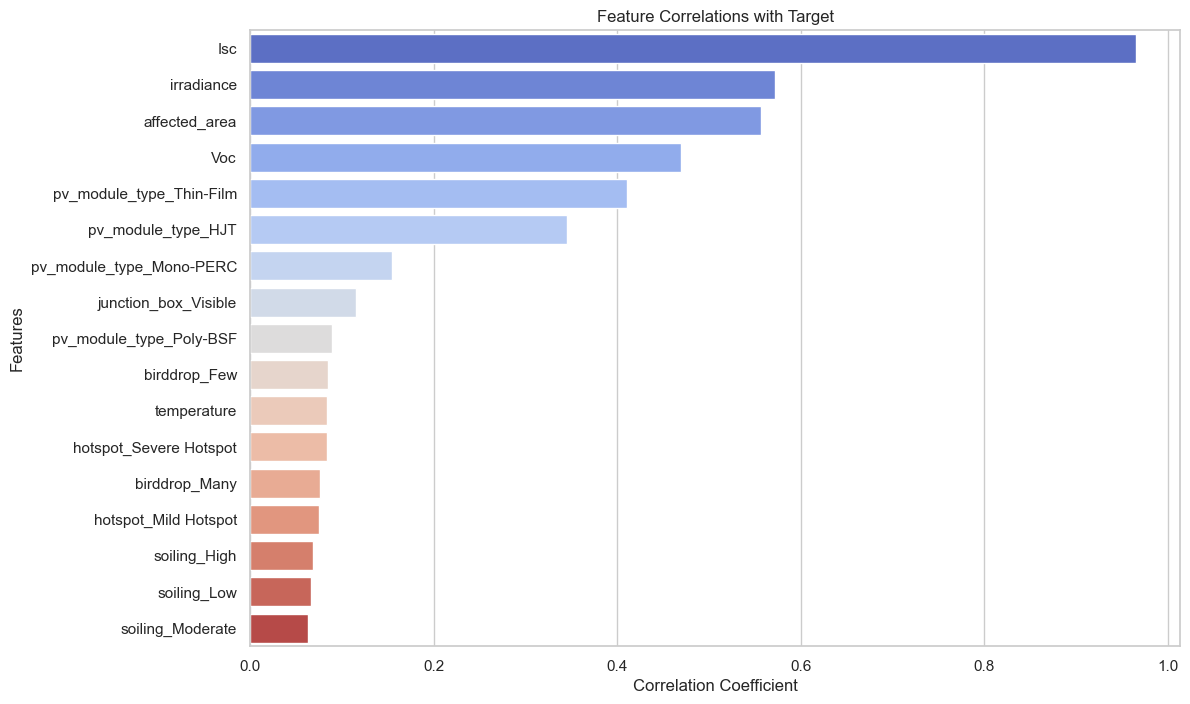

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr, pointbiserialr

# Dictionary to store correlations
correlations = {}

def is_normal(col):
    # Statistical tests
        stat, p_value = shapiro(col)
        return p_value > 0.05

# Iterate over each column in the dataset
for col in data.columns:
    if col != 'target':  # Skip the target column
        if data[col].nunique() > 2:  # Continuous variable
            # Use Pearson or Spearman depending on normality
            if is_normal(data[col]): 
                corr, _ = pearsonr(data[col], data['target'])
                correlations[col] = corr
            else:
                corr, _ = spearmanr(data[col], data['target'])
                correlations[col] = corr
        elif data[col].nunique() == 2:  # Binary variable
            # Use Point-Biserial for binary variables
            corr, _ = pointbiserialr(data[col], data['target'])
            correlations[col] = corr

# Convert correlations dictionary to a Pandas Series for plotting
correlations_series = pd.Series(correlations)

# Sort correlations by absolute value for better visualization
correlations_series = correlations_series.abs().sort_values(ascending=False)

# Define a color palette (optional)
colors = sns.color_palette("coolwarm", len(correlations_series))

# Plot the correlations
plt.figure(figsize=(12, 8))
sns.barplot(x=correlations_series.values, y=correlations_series.index, palette=colors)
plt.title('Feature Correlations with Target')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.show()


### Interpretation of Results
1. Very Strong Correlation (|correlation| ≥ 0.7):
    Isc.
    Therefore, we should retain this feature in the model. The very strong correlation indicates that this feature is highly significant in predicting the target variable.
    
2. Strong Correlation (0.5 ≤ |correlation| < 0.7):
    Irradiance and affected area.
    We should also retain these features in the model, since they are significantly important for predicting the target variable.

3. Moderate Correlation (0.3 ≤ |correlation| < 0.5):
    Voc, PV module type Thin-film and PV module type HJT.
    Although the correlation value is not high, we should also retain these features in the model, since they can still provide valuable information for predicting the target variable.

4. Weak Correlation (|correlation| < 0.3):
    remaining features.
    Due to its value, we could consider removing these features from the model. Weak correlations indicate that these features may not significantly contribute to predicting the target variable and may introduce noise into the model. Although, even if a feature has weak correlation, a combination of the feature with others may be important to the final. For example, it might be beneficial to keep temperature in the model to capture its influence on Voc, as was showned in the scatter plot analysis.


Therefore, we can:
- retain the features: Isc, Irradiance, affected area, Voc, PV module type Thin-film, PV module type HJT and temperature;
- remove the remaining features

After this, we'll re-evaluate the models to check for improved performance by cross-validation to assess the impact of feature removal. This will be done after choosing the most appropriate models for this dataset in the cross-validation notebook.